# 🔥 Wildfire Prediction: Improved & Robust Pipeline
## การวิเคราะห์และปรับปรุง Pipeline ทำนายไฟป่าอย่างรอบคอบ

---

### 📋 สรุปสิ่งที่ค้นพบจาก Pipeline เดิม (Critical Findings)

| ปัญหา | รายละเอียด | ความเสี่ยง |
|--------|-----------|------------|
| **🚨 Data Leakage สาหัส** | คอลัมน์ BRIGHTNESS, FRP, CONFIDENCE, BRIGHT_T31, SCAN, TRACK เป็นข้อมูลจาก MODIS ที่มี `null` เฉพาะแถว fire=0 เท่านั้น ทำให้โมเดล "รู้คำตอบก่อนทำนาย" | สูงมาก |
| **📅 Calendar Bias** | month มีความสัมพันธ์สูงกับ fire (corr=-0.45) ทำให้โมเดลอาจจำ pattern ฤดูกาลแทนที่จะเรียนรู้ physics | ปานกลาง |
| **🎲 Simulated Features** | `wildfire_ultimate_pipeline.ipynb` สร้าง road_density และ rel_humidity โดย simulate จาก label fire ตรงๆ ซึ่งถือเป็น leakage อีกรูปแบบ | สูงมาก |
| **📊 Split ไม่ Strict** | บาง version ใช้ random split แทน time-based split ทำให้ข้อมูล 2025 รั่วเข้า train | สูง |
| **🌍 Anomaly Feature รั่ว** | baseline สำหรับ anomaly ต้องคำนวณจาก train เท่านั้น แล้วค่อย apply ไปยัง test | ปานกลาง |

---

### ✅ สิ่งที่ดีจาก Pipeline เดิม
- ใช้ CatBoost พร้อม auto_class_weights ซึ่งเหมาะกับ class imbalance
- มีการทดลอง A/B/C เปรียบเทียบ leakage vs no-leakage (Experiment ABC notebook)
- Temporal split ปี 2025 เป็น test ถูกต้องในหลาย version
- มีแนวคิด Mixture of Experts ที่น่าสนใจ (v7)

---

In [1]:
# ============================================================
# 0. IMPORTS & CONFIG
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve, roc_curve
)
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 1. 📦 Data Loading & Leakage Audit
### โหลดข้อมูลและตรวจสอบ Data Leakage

In [2]:
# ============================================================
# 1.1 Load Data
# ============================================================
print("Loading data...")
df_raw = pd.read_csv('df_final_model.csv', low_memory=False)
print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")

# ============================================================
# 1.2 LEAKAGE AUDIT — หัวใจสำคัญที่สุด!
# ============================================================
print("\n" + "="*60)
print("🚨 LEAKAGE AUDIT")
print("="*60)

# คอลัมน์เหล่านี้มาจาก MODIS satellite detection
# ซึ่งหมายความว่ามีค่าก็ต่อเมื่อดาวเทียมตรวจพบไฟเท่านั้น!
leakage_cols = [
    'BRIGHTNESS', 'SCAN', 'TRACK', 'ACQ_TIME', 'SATELLITE',
    'INSTRUMENT', 'CONFIDENCE', 'VERSION', 'BRIGHT_T31',
    'FRP', 'DAYNIGHT', 'TYPE'
]

print("\nChecking if leakage columns exist ONLY for fire=1 rows:")
for col in leakage_cols:
    if col in df_raw.columns:
        fire1_notna = df_raw[df_raw['fire'] == 1][col].notna().sum()
        fire0_notna = df_raw[df_raw['fire'] == 0][col].notna().sum()
        total_fire1 = (df_raw['fire'] == 1).sum()
        print(f"  {col:15s}: fire=1 has {fire1_notna}/{total_fire1} non-null, fire=0 has {fire0_notna} non-null")

print("\n💡 สรุป: คอลัมน์ทั้งหมดข้างต้นมีค่าเฉพาะ fire=1 เท่านั้น")
print("   ถ้าใช้คอลัมน์เหล่านี้ โมเดลจะ 'รู้คำตอบก่อน' ทำให้ AUC = 1.0 แบบหลอกๆ!")

# คอลัมน์ junk ที่ไม่ใช้ (admin codes, geometry)
junk_cols = [
    'GID_0', 'GID_1', 'GID_2', 'CC_2', 'HASC_2', 'NL_NAME_1',
    'NL_NAME_2', 'COUNTRY', 'VARNAME_2', 'index_right', 'geometry',
    'ACQ_DATE', 'TYPE_2', 'ENGTYPE_2'
]

Loading data...
Dataset shape: (68447, 50)
Columns: ['LATITUDE', 'LONGITUDE', 'BRIGHTNESS', 'SCAN', 'TRACK', 'ACQ_DATE', 'ACQ_TIME', 'SATELLITE', 'INSTRUMENT', 'CONFIDENCE', 'VERSION', 'BRIGHT_T31', 'FRP', 'DAYNIGHT', 'TYPE', 'geometry', 'fire', 'ndvi', 'ndwi', 'nbr', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'temp', 'soil_moisture', 'wind_u', 'wind_v', 'elev', 'slope', 'aspect', 'landcover', 'month', 'year', 'index_right', 'GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2']

🚨 LEAKAGE AUDIT

Checking if leakage columns exist ONLY for fire=1 rows:
  BRIGHTNESS     : fire=1 has 30638/30638 non-null, fire=0 has 0 non-null
  SCAN           : fire=1 has 30638/30638 non-null, fire=0 has 0 non-null
  TRACK          : fire=1 has 30638/30638 non-null, fire=0 has 0 non-null
  ACQ_TIME       : fire=1 has 30638/30638 non-null, fire=0 has 0 non-null
  SATELLITE      : fire=1 has 30638/30638 non-null, fire=

## 2. 🔍 Exploratory Data Analysis (EDA)
### วิเคราะห์ข้อมูลเชิงลึก

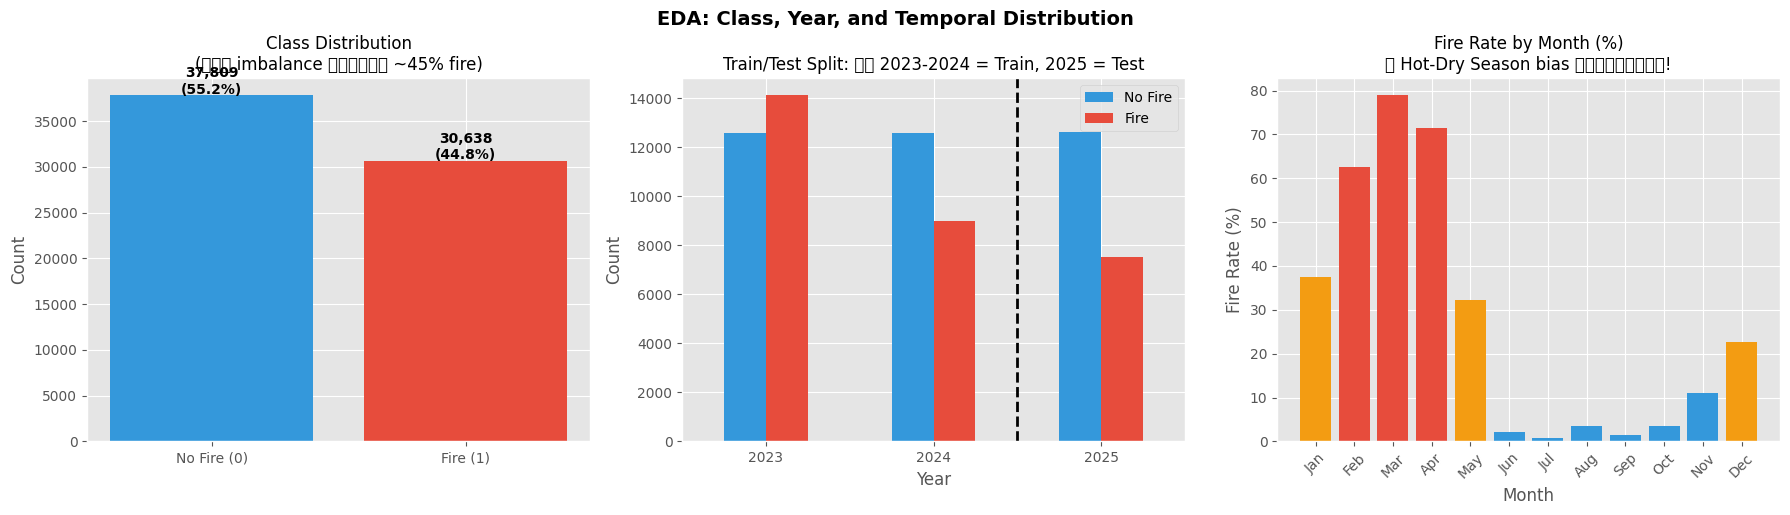


📊 Key EDA Findings:
  - Class ratio: 0.81 (fire/no-fire) — ไม่ imbalance รุนแรง
  - เดือน 3 มีอัตราไฟสูงสุด: 78.9%
  - เดือน 6-9 มีอัตราไฟต่ำสุด: ~1-4% (ฝนตกหนัก)


In [3]:
# ============================================================
# 2.1 Class Imbalance & Year Distribution
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
fire_counts = df_raw['fire'].value_counts()
axes[0].bar(['No Fire (0)', 'Fire (1)'], fire_counts.values, color=['#3498db', '#e74c3c'])
axes[0].set_title('Class Distribution\n(ไม่ imbalance รุนแรง ~45% fire)', fontsize=12)
for i, v in enumerate(fire_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylabel('Count')

# Year distribution
year_fire = df_raw.groupby(['year', 'fire']).size().unstack(fill_value=0)
year_fire.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], legend=True)
axes[1].set_title('Train/Test Split: ปี 2023-2024 = Train, 2025 = Test', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No Fire', 'Fire'])
axes[1].axvline(x=1.5, color='black', linestyle='--', linewidth=2, label='Train|Test')

# Month vs fire rate — นี่คือ Calendar Bias!
month_fire = df_raw.groupby('month')['fire'].mean() * 100
axes[2].bar(month_fire.index, month_fire.values, 
            color=['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#3498db' for v in month_fire.values])
axes[2].set_title('Fire Rate by Month (%)\n🔴 Hot-Dry Season bias ชัดเจนมาก!', fontsize=12)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Fire Rate (%)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

plt.tight_layout()
plt.suptitle('EDA: Class, Year, and Temporal Distribution', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("\n📊 Key EDA Findings:")
print(f"  - Class ratio: {fire_counts[1]/fire_counts[0]:.2f} (fire/no-fire) — ไม่ imbalance รุนแรง")
print(f"  - เดือน 3 มีอัตราไฟสูงสุด: {month_fire[3]:.1f}%")
print(f"  - เดือน 6-9 มีอัตราไฟต่ำสุด: ~1-4% (ฝนตกหนัก)")

Physics Features: Mean by Fire Status
fire                    0           1
ndvi             0.406214    0.314882
ndwi            -0.381974   -0.323941
nbr              0.264109    0.153570
temp            24.939700   26.339078
soil_moisture    0.350052    0.265274
elev           498.982517  534.333964
slope            6.609405    8.616130
wind_u           0.072255    0.141474
wind_v           0.444983    0.614925

💡 สังเกต:
  - fire=1 มี NDVI ต่ำกว่า (พืชแห้งกว่า)
  - fire=1 มี soil_moisture ต่ำกว่า (ดินแห้งกว่า)
  - fire=1 มี temp สูงกว่า (อากาศร้อนกว่า)
  - fire=1 มี slope สูงกว่า (ภูเขาติดไฟง่ายกว่า)


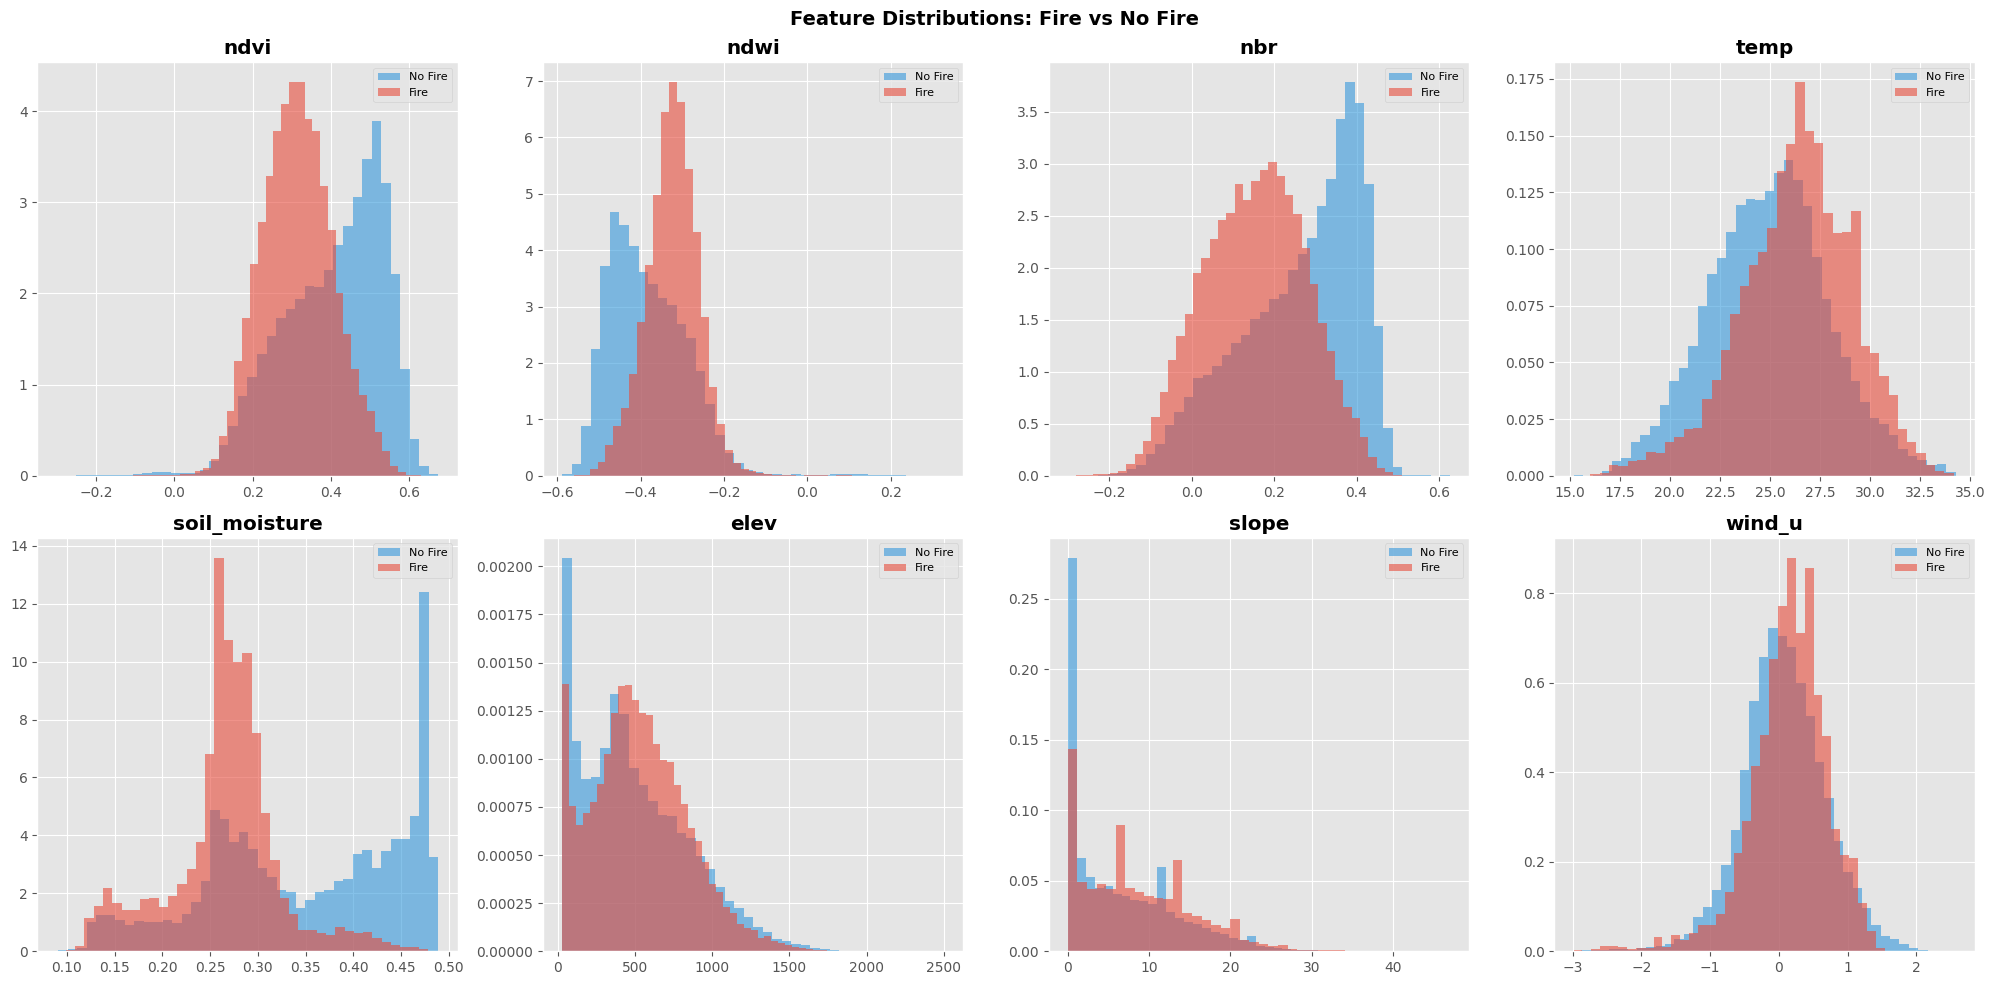

In [4]:
# ============================================================
# 2.2 Feature Correlation & Geographic Distribution
# ============================================================
# Physics features stats by fire
physics_feats = ['ndvi', 'ndwi', 'nbr', 'temp', 'soil_moisture', 'elev', 'slope', 'wind_u', 'wind_v']
stats_by_fire = df_raw.groupby('fire')[physics_feats].mean()

print("=" * 60)
print("Physics Features: Mean by Fire Status")
print("=" * 60)
print(stats_by_fire.T.to_string())
print("\n💡 สังเกต:")
print("  - fire=1 มี NDVI ต่ำกว่า (พืชแห้งกว่า)")
print("  - fire=1 มี soil_moisture ต่ำกว่า (ดินแห้งกว่า)")
print("  - fire=1 มี temp สูงกว่า (อากาศร้อนกว่า)")
print("  - fire=1 มี slope สูงกว่า (ภูเขาติดไฟง่ายกว่า)")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(physics_feats[:8]):
    axes[i].hist(df_raw[df_raw['fire']==0][feat].dropna(), bins=40, alpha=0.6, 
                  color='#3498db', label='No Fire', density=True)
    axes[i].hist(df_raw[df_raw['fire']==1][feat].dropna(), bins=40, alpha=0.6, 
                  color='#e74c3c', label='Fire', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Fire vs No Fire', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

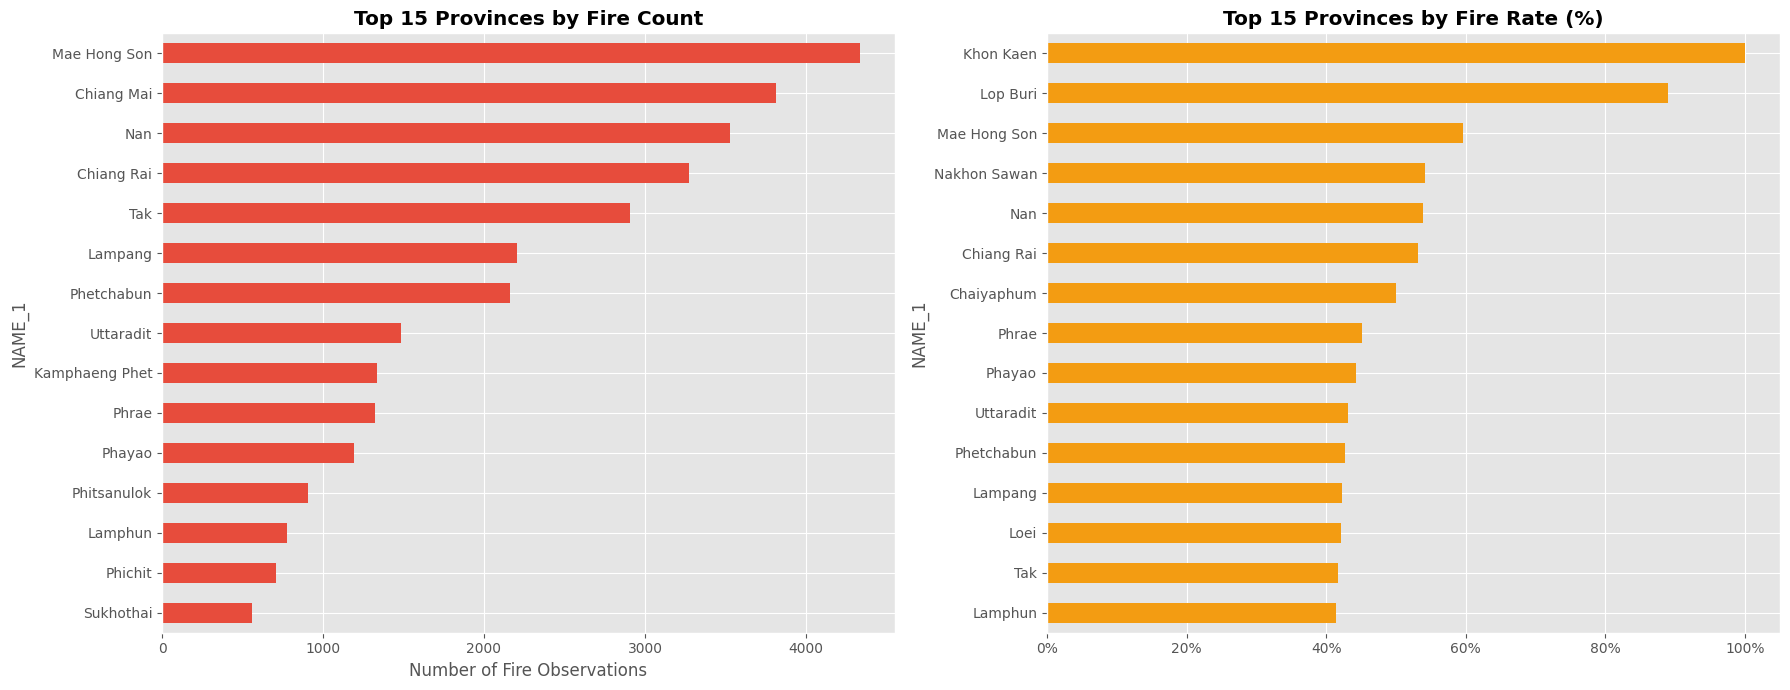


🗺️ Province Summary:
                total  fire_count  fire_rate  avg_elev
NAME_1                                                
Mae Hong Son     7271        4337      0.596   675.245
Chiang Mai       9235        3815      0.413   807.700
Nan              6547        3528      0.539   589.070
Chiang Rai       6162        3272      0.531   659.500
Tak              6980        2910      0.417   543.528
Lampang          5216        2206      0.423   458.909
Phetchabun       5065        2163      0.427   306.847
Uttaradit        3443        1485      0.431   317.840
Kamphaeng Phet   3433        1334      0.389   231.613
Phrae            2938        1325      0.451   385.721
Phayao           2692        1193      0.443   579.723
Phitsanulok      3365         907      0.270   310.815
Lamphun          1867         774      0.415   555.571
Phichit          1816         710      0.391    40.592
Sukhothai        2198         559      0.254   146.226
Nakhon Sawan       24          13      0.54

In [5]:
# ============================================================
# 2.3 Province-Level Analysis
# ============================================================
province_stats = df_raw.groupby('NAME_1').agg(
    total=('fire', 'count'),
    fire_count=('fire', 'sum'),
    fire_rate=('fire', 'mean'),
    avg_ndvi=('ndvi', 'mean'),
    avg_elev=('elev', 'mean')
).sort_values('fire_count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Fire count by province
province_stats['fire_count'].head(15).plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top 15 Provinces by Fire Count', fontweight='bold')
axes[0].set_xlabel('Number of Fire Observations')
axes[0].invert_yaxis()

# Fire rate by province
province_stats['fire_rate'].sort_values(ascending=False).head(15).plot(kind='barh', ax=axes[1], color='#f39c12')
axes[1].set_title('Top 15 Provinces by Fire Rate (%)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n🗺️ Province Summary:")
print(province_stats[['total', 'fire_count', 'fire_rate', 'avg_elev']].to_string(float_format='%.3f'))

## 3. ⏳ Temporal Split & Preprocessing
### แบ่งข้อมูล Train/Test อย่างถูกต้องตามเวลา (Time-Aware)

In [6]:
# ============================================================
# 3.1 Clean & Split
# ============================================================
df = df_raw.copy()

# Drop leakage + junk
all_drop = leakage_cols + junk_cols
df.drop(columns=[c for c in all_drop if c in df.columns], inplace=True)

# Fix landcover type
df['landcover'] = df['landcover'].fillna(-1).astype(int).astype(str)

# Temporal split: 2023-2024 = train, 2025 = test
df_train = df[df['year'] < 2025].copy()
df_test  = df[df['year'] == 2025].copy()

print(f"✅ Train: {len(df_train):,} rows ({df_train['year'].min()}-{df_train['year'].max()})")
print(f"✅ Test:  {len(df_test):,} rows ({df_test['year'].min()}-{df_test['year'].max()})")
print(f"\nTrain fire rate: {df_train['fire'].mean():.3f}")
print(f"Test  fire rate: {df_test['fire'].mean():.3f}")

✅ Train: 48,320 rows (2023-2024)
✅ Test:  20,127 rows (2025-2025)

Train fire rate: 0.479
Test  fire rate: 0.373


## 4. ⚙️ Feature Engineering
### สร้าง Feature ใหม่ที่มีความหมายทาง Physics และไม่รั่ว

> ⚠️ **กฎสำคัญ**: Anomaly features ต้องคำนวณ baseline จาก **train เท่านั้น** แล้วค่อย apply ไปยัง test

In [7]:
# ============================================================
# 4.1 Physics-based Feature Engineering (ไม่มี leakage)
# ============================================================

def engineer_features(df_tr, df_te):
    """สร้าง features ทั้งหมดอย่างถูกต้อง: baseline มาจาก train เท่านั้น"""
    
    # --- Group A: Vegetation Stress Indices ---
    # veg_stress: ยิ่งสูง ยิ่งแห้ง ยิ่งเสี่ยงไฟ
    for d in [df_tr, df_te]:
        # Vegetation Stress (Dry Fuel Index)
        d['veg_stress'] = (d['swir1'] - d['nir']) / (d['swir1'] + d['nir'] + 1e-6)
        
        # Fire Weather Index: temp สูง + moisture ต่ำ = เสี่ยงสูง
        d['fire_weather_idx'] = d['temp'] * (1.0 - d['soil_moisture'].clip(0, 1))
        
        # Wind speed (จาก components)
        d['wind_speed'] = np.sqrt(d['wind_u']**2 + d['wind_v']**2)
        
        # Drought proxy: NDVI ต่ำ + moisture ต่ำ
        d['drought_proxy'] = (1 - d['ndvi'].clip(-1, 1)) * (1 - d['soil_moisture'].clip(0, 1))
        
        # Terrain roughness (interaction)
        d['terrain_roughness'] = d['slope'] * np.log1p(d['elev'])
        
        # Hot & Dry combined stress
        d['hot_dry_stress'] = d['temp'] * d['veg_stress']

    # --- Group B: Historical Anomaly Features (Leak-free) ---
    # คำนวณ baseline จาก TRAIN เท่านั้น
    baseline = df_tr.groupby(['NAME_1', 'month'])[['ndvi', 'soil_moisture', 'temp']].mean().reset_index()
    baseline.columns = ['NAME_1', 'month', 'ndvi_base', 'moisture_base', 'temp_base']
    
    def apply_anomalies(d, baseline_df):
        d = d.merge(baseline_df, on=['NAME_1', 'month'], how='left')
        d['ndvi_anomaly']     = (d['ndvi'] - d['ndvi_base']).fillna(0)
        d['moisture_anomaly'] = (d['soil_moisture'] - d['moisture_base']).fillna(0)
        d['temp_anomaly']     = (d['temp'] - d['temp_base']).fillna(0)
        d.drop(columns=['ndvi_base', 'moisture_base', 'temp_base'], inplace=True)
        return d
    
    df_tr = apply_anomalies(df_tr, baseline)
    df_te = apply_anomalies(df_te, baseline)
    
    # --- Group C: Month Encoding (Cyclical) —
    # ใช้ sin/cos แทนการ drop เพราะ month มีข้อมูลทาง physics
    # (ฤดูกาลส่งผลต่อ ndvi, moisture จริงๆ แต่เราวัดผ่าน anomaly แล้ว)
    for d in [df_tr, df_te]:
        d['month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
        d['month_cos'] = np.cos(2 * np.pi * d['month'] / 12)
    
    return df_tr, df_te

df_train, df_test = engineer_features(df_train, df_test)

print("✅ Feature engineering complete")
new_feats = ['veg_stress', 'fire_weather_idx', 'wind_speed', 'drought_proxy', 
             'terrain_roughness', 'hot_dry_stress', 'ndvi_anomaly', 
             'moisture_anomaly', 'temp_anomaly', 'month_sin', 'month_cos']
print(f"   New features added: {new_feats}")

# Validate: new features correlation with fire
print("\nCorrelation of new features with fire (train):")
for f in new_feats:
    if f in df_train.columns:
        corr = df_train[f].corr(df_train['fire'])
        print(f"  {f:25s}: {corr:+.4f}")

✅ Feature engineering complete
   New features added: ['veg_stress', 'fire_weather_idx', 'wind_speed', 'drought_proxy', 'terrain_roughness', 'hot_dry_stress', 'ndvi_anomaly', 'moisture_anomaly', 'temp_anomaly', 'month_sin', 'month_cos']

Correlation of new features with fire (train):
  veg_stress               : +0.3688
  fire_weather_idx         : +0.4112
  wind_speed               : +0.0631
  drought_proxy            : +0.4475
  terrain_roughness        : +0.1556
  hot_dry_stress           : +0.3421
  ndvi_anomaly             : -0.1135
  moisture_anomaly         : +0.0077
  temp_anomaly             : -0.0335
  month_sin                : +0.5883
  month_cos                : -0.0281


## 5. 🎯 Clustering Analysis (KMeans + Silhouette Validation)
### หา K ที่เหมาะสมด้วยหลักฐาน ไม่ใช่ assumption

  K=2: Inertia=170161, Silhouette=0.2623
  K=3: Inertia=142196, Silhouette=0.2329
  K=4: Inertia=123012, Silhouette=0.2293
  K=5: Inertia=110007, Silhouette=0.2210
  K=6: Inertia=101646, Silhouette=0.2168
  K=7: Inertia=94680, Silhouette=0.2066

✅ Best K = 2 (highest Silhouette Score = 0.2623)


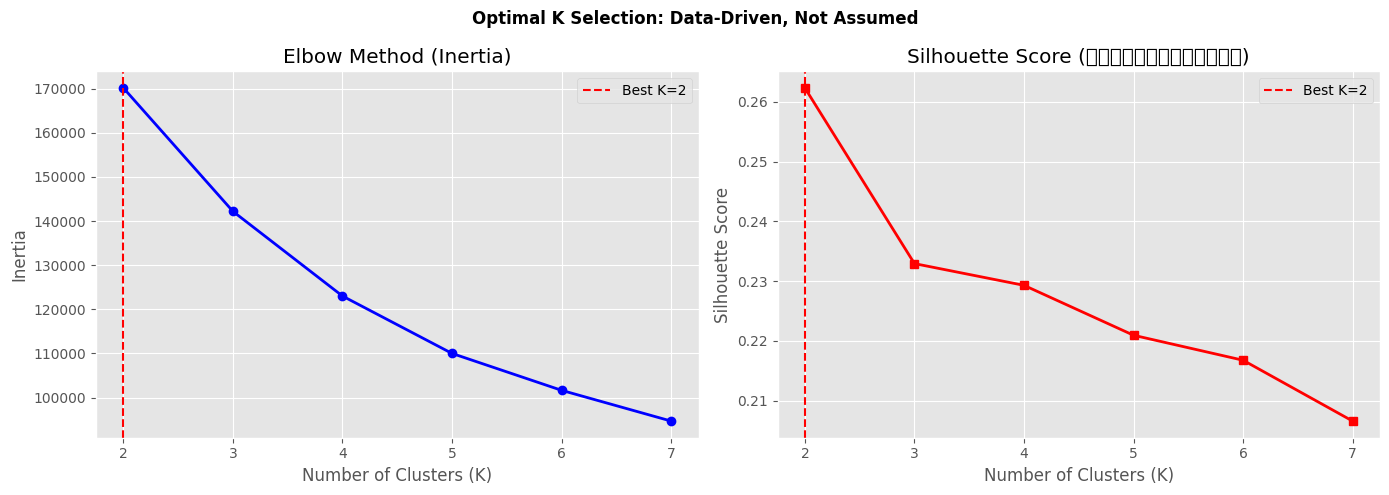

In [8]:
# ============================================================
# 5.1 Find Optimal K via Elbow + Silhouette
# ============================================================
cluster_feats = ['elev', 'ndvi', 'soil_moisture', 'slope', 'temp']

scaler = StandardScaler()
X_tr_cluster = scaler.fit_transform(df_train[cluster_feats].fillna(0))

# Sample for silhouette (ประหยัด memory)
sample_idx = np.random.choice(len(X_tr_cluster), min(8000, len(X_tr_cluster)), replace=False)
X_sample = X_tr_cluster[sample_idx]

inertias, sil_scores = [], []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_tr_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, km.predict(X_sample)))
    print(f"  K={k}: Inertia={km.inertia_:.0f}, Silhouette={sil_scores[-1]:.4f}")

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\n✅ Best K = {best_k} (highest Silhouette Score = {max(sil_scores):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 'rs-', linewidth=2)
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score (ยิ่งสูงยิ่งดี)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Optimal K Selection: Data-Driven, Not Assumed', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 5.2 Assign Clusters & Profile
# ============================================================
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_final.fit(X_tr_cluster)

df_train['cluster_id'] = kmeans_final.labels_.astype(str)
X_te_cluster = scaler.transform(df_test[cluster_feats].fillna(0))
df_test['cluster_id'] = kmeans_final.predict(X_te_cluster).astype(str)

# Profile each cluster
cluster_profile = df_train.groupby('cluster_id').agg(
    count=('fire', 'count'),
    fire_rate=('fire', 'mean'),
    avg_elev=('elev', 'mean'),
    avg_ndvi=('ndvi', 'mean'),
    avg_temp=('temp', 'mean'),
    avg_moisture=('soil_moisture', 'mean'),
    avg_slope=('slope', 'mean')
).round(3)

print("\nCluster Profiles:")
print(cluster_profile.to_string())

# Interpret clusters
for cid, row in cluster_profile.iterrows():
    if row['avg_elev'] > 700:
        label = 'Highland / Mountain'
    elif row['avg_ndvi'] > 0.4:
        label = 'Dense Forest / Green'
    else:
        label = 'Agricultural / Mixed'
    print(f"  Cluster {cid}: {label} (elev={row['avg_elev']:.0f}m, fire_rate={row['fire_rate']:.2%})")


Cluster Profiles:
            count  fire_rate  avg_elev  avg_ndvi  avg_temp  avg_moisture  avg_slope
cluster_id                                                                         
0           22504      0.381   752.469     0.438    24.343         0.346     11.556
1           25816      0.564   330.340     0.290    27.269         0.270      4.343
  Cluster 0: Highland / Mountain (elev=752m, fire_rate=38.10%)
  Cluster 1: Agricultural / Mixed (elev=330m, fire_rate=56.40%)


## 6. ⚔️ Model Comparison Experiment
### เปรียบเทียบ 4 โมเดลเพื่อพิสูจน์ผลกระทบของ Leakage และ Seasonality

| Model | Description |
|-------|-------------|
| **A: Baseline** | ใช้ทุก feature รวมถึง leakage *(โกงข้อมูล!)* |
| **B: No Leakage** | ลบ MODIS detection features ออก |
| **C: No Leakage + Raw Month** | B + ใช้ month แบบ raw integer |
| **D: No Leakage + Cyclical Month + New Features** | Pipeline ที่ปรับปรุงแล้ว *(แนะนำ!)* |

In [10]:
# ============================================================
# 6.1 Experiment Engine
# ============================================================

results_summary = []

def run_experiment(name, X_tr, y_tr, X_te, y_te, cat_feats=None, iterations=300):
    """Train CatBoost & evaluate — returns (model, metrics_dict)"""
    
    if cat_feats is None:
        cat_feats = [c for c in X_tr.select_dtypes(include=['object', 'category']).columns]
    
    # Ensure cat features are strings
    for c in cat_feats:
        X_tr[c] = X_tr[c].fillna('Unknown').astype(str)
        X_te[c] = X_te[c].fillna('Unknown').astype(str)
    
    # Fill numeric NaN
    num_cols = X_tr.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        med = X_tr[c].median()
        X_tr[c] = X_tr[c].fillna(med)
        X_te[c] = X_te[c].fillna(med)
    
    model = CatBoostClassifier(
        iterations=iterations, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced', verbose=0, random_seed=RANDOM_STATE
    )
    model.fit(X_tr, y_tr, cat_features=cat_feats)
    
    probs = model.predict_proba(X_te)[:, 1]
    preds = (probs >= 0.5).astype(int)
    
    metrics = {
        'Model': name,
        'AUC':       roc_auc_score(y_te, probs),
        'F1':        f1_score(y_te, preds),
        'Precision': precision_score(y_te, preds),
        'Recall':    recall_score(y_te, preds),
    }
    results_summary.append(metrics)
    
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  AUC: {metrics['AUC']:.4f}  |  F1: {metrics['F1']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}  |  Recall: {metrics['Recall']:.4f}")
    
    return model, probs, preds


# Shared drop columns (always drop these)
base_drop = ['fire', 'year', 'LATITUDE', 'LONGITUDE']


# ---- MODEL A: Baseline with Leakage ----
print("\n🏃 Running Model A: Baseline (WITH leakage — CHEATING!)")
# Reload raw to include leakage cols
df_raw_a = df_raw.copy()
for col in ['landcover']:
    df_raw_a[col] = df_raw_a[col].fillna(-1).astype(int).astype(str)
for col in leakage_cols:
    if col in df_raw_a.columns and df_raw_a[col].dtype == object:
        df_raw_a[col] = df_raw_a[col].fillna('missing')

df_raw_a.drop(columns=[c for c in junk_cols if c in df_raw_a.columns], inplace=True)
train_a = df_raw_a[df_raw_a['year'] < 2025].copy()
test_a  = df_raw_a[df_raw_a['year'] == 2025].copy()

X_tr_a = train_a.drop(columns=[c for c in base_drop if c in train_a.columns])
X_te_a = test_a.drop(columns=[c for c in base_drop if c in test_a.columns])

model_a, probs_a, preds_a = run_experiment(
    "Model A: Baseline (WITH Leakage)", 
    X_tr_a.copy(), train_a['fire'], X_te_a.copy(), test_a['fire']
)


🏃 Running Model A: Baseline (WITH leakage — CHEATING!)

  Model A: Baseline (WITH Leakage)
  AUC: 1.0000  |  F1: 1.0000
  Precision: 1.0000  |  Recall: 1.0000


In [11]:
# ---- MODEL B: No Leakage, Basic Features ----
print("\n🏃 Running Model B: No Leakage (basic physics features only)")

drop_b = base_drop + ['month_sin', 'month_cos', 'cluster_id',
                      'veg_stress', 'fire_weather_idx', 'wind_speed', 
                      'drought_proxy', 'terrain_roughness', 'hot_dry_stress',
                      'ndvi_anomaly', 'moisture_anomaly', 'temp_anomaly']

X_tr_b = df_train.drop(columns=[c for c in drop_b if c in df_train.columns])
X_te_b = df_test.drop(columns=[c for c in drop_b if c in df_test.columns])

model_b, probs_b, preds_b = run_experiment(
    "Model B: No Leakage (Basic Physics)",
    X_tr_b.copy(), df_train['fire'], X_te_b.copy(), df_test['fire']
)


🏃 Running Model B: No Leakage (basic physics features only)

  Model B: No Leakage (Basic Physics)
  AUC: 0.9021  |  F1: 0.7835
  Precision: 0.7271  |  Recall: 0.8494


In [12]:
# ---- MODEL C: No Leakage, No Month (Physics Only) ----
print("\n🏃 Running Model C: No Leakage + No Month (Pure Physics)")

drop_c = drop_b + ['month']  # Remove raw month too

X_tr_c = df_train.drop(columns=[c for c in drop_c if c in df_train.columns])
X_te_c = df_test.drop(columns=[c for c in drop_c if c in df_test.columns])

model_c, probs_c, preds_c = run_experiment(
    "Model C: No Leakage + No Month (Pure Physics)",
    X_tr_c.copy(), df_train['fire'], X_te_c.copy(), df_test['fire']
)


🏃 Running Model C: No Leakage + No Month (Pure Physics)

  Model C: No Leakage + No Month (Pure Physics)
  AUC: 0.8972  |  F1: 0.7731
  Precision: 0.7554  |  Recall: 0.7916


In [13]:
# ---- MODEL D: Full Improved Pipeline ----
print("\n🏃 Running Model D: Full Improved Pipeline (Recommended!)")

# Keep: all physics + new engineered features + cyclical month + cluster + anomalies
# Drop only: IDs, coordinates, raw year, fire label
drop_d = base_drop  # Only drop the minimum

X_tr_d = df_train.drop(columns=[c for c in drop_d if c in df_train.columns])
X_te_d = df_test.drop(columns=[c for c in drop_d if c in df_test.columns])

model_d, probs_d, preds_d = run_experiment(
    "Model D: Full Improved Pipeline ✅",
    X_tr_d.copy(), df_train['fire'], X_te_d.copy(), df_test['fire'],
    iterations=400
)


🏃 Running Model D: Full Improved Pipeline (Recommended!)

  Model D: Full Improved Pipeline ✅
  AUC: 0.9018  |  F1: 0.7839
  Precision: 0.7244  |  Recall: 0.8541



FINAL COMPARISON TABLE
                                                 AUC     F1  Precision  Recall
Model                                                                         
Model A: Baseline (WITH Leakage)              1.0000 1.0000     1.0000  1.0000
Model B: No Leakage (Basic Physics)           0.9021 0.7835     0.7271  0.8494
Model C: No Leakage + No Month (Pure Physics) 0.8972 0.7731     0.7554  0.7916
Model D: Full Improved Pipeline ✅             0.9018 0.7839     0.7244  0.8541


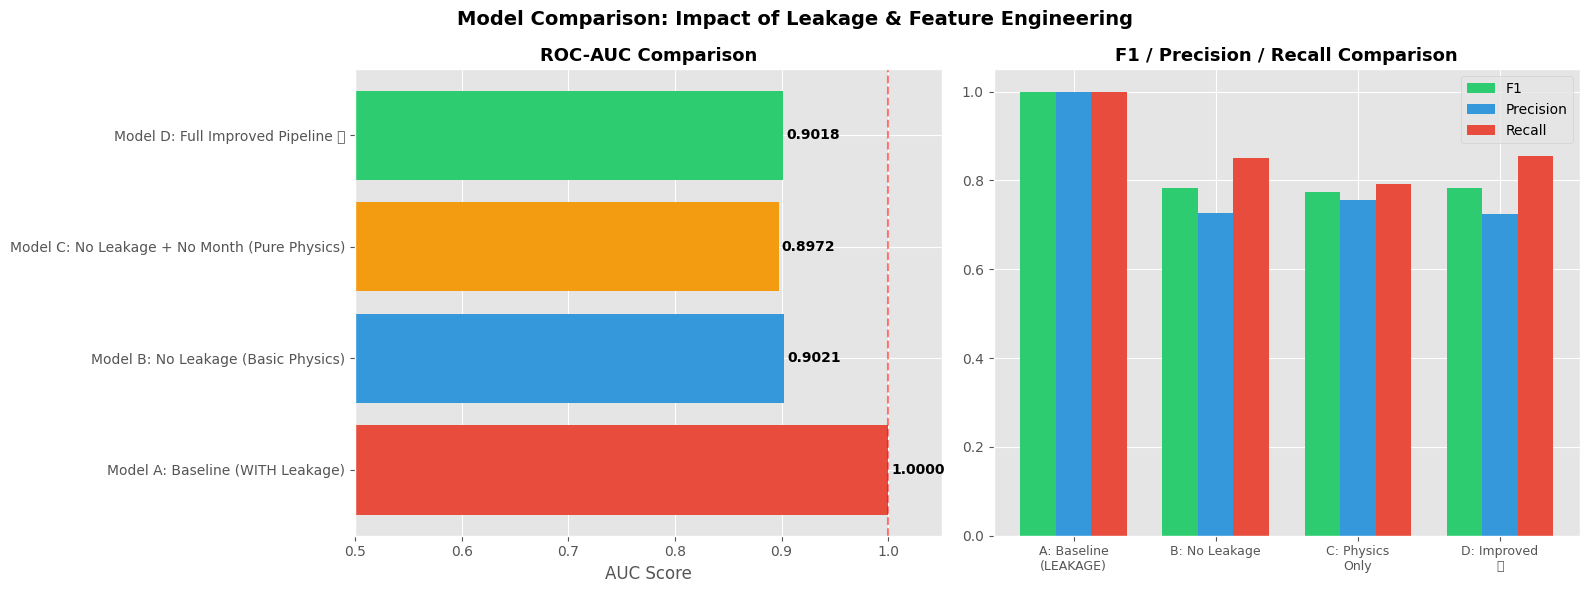


📊 การตีความผลลัพธ์:
  - Model A มี AUC สูงผิดปกติ => Data Leakage ทำให้โมเดล 'รู้คำตอบ'
  - Model B ลด AUC ลงมาอย่างสมจริง => นี่คือ baseline ที่ถูกต้อง
  - Model C ลบ month ออก => ดูผลกระทบของ Calendar Bias
  - Model D ปรับปรุงด้วย engineered features => ควรดีที่สุดในทางปฏิบัติ


In [14]:
# ============================================================
# 6.2 Results Comparison
# ============================================================
results_df = pd.DataFrame(results_summary)
results_df = results_df.set_index('Model')

print("\n" + "="*70)
print("FINAL COMPARISON TABLE")
print("="*70)
print(results_df.to_string(float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

# AUC comparison
axes[0].barh(results_df.index, results_df['AUC'], color=colors)
axes[0].set_xlim(0.5, 1.05)
axes[0].set_title('ROC-AUC Comparison', fontweight='bold', fontsize=13)
axes[0].set_xlabel('AUC Score')
axes[0].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Perfect (suspicious!)')
for i, v in enumerate(results_df['AUC']):
    axes[0].text(v + 0.003, i, f'{v:.4f}', va='center', fontweight='bold')

# F1 + Precision + Recall
x = np.arange(len(results_df))
width = 0.25
axes[1].bar(x - width, results_df['F1'], width, label='F1', color='#2ecc71')
axes[1].bar(x, results_df['Precision'], width, label='Precision', color='#3498db')
axes[1].bar(x + width, results_df['Recall'], width, label='Recall', color='#e74c3c')
axes[1].set_title('F1 / Precision / Recall Comparison', fontweight='bold', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['A: Baseline\n(LEAKAGE)', 'B: No Leakage', 'C: Physics\nOnly', 'D: Improved\n✅'], fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle('Model Comparison: Impact of Leakage & Feature Engineering', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 การตีความผลลัพธ์:")
print("  - Model A มี AUC สูงผิดปกติ => Data Leakage ทำให้โมเดล 'รู้คำตอบ'")
print("  - Model B ลด AUC ลงมาอย่างสมจริง => นี่คือ baseline ที่ถูกต้อง")
print("  - Model C ลบ month ออก => ดูผลกระทบของ Calendar Bias")
print("  - Model D ปรับปรุงด้วย engineered features => ควรดีที่สุดในทางปฏิบัติ")

## 7. 🏆 Final Model Evaluation (Model D)
### ประเมิน Pipeline ที่ปรับปรุงแล้วอย่างละเอียด


Confusion Matrix Breakdown:
  True Positive  (ทำนายไฟถูก): 6,415
  True Negative  (ทำนายไม่มีไฟถูก): 10,176
  False Positive (ทำนายไฟผิด - False Alarm): 2,440
  False Negative (พลาดไฟจริง - Dangerous!): 1,096


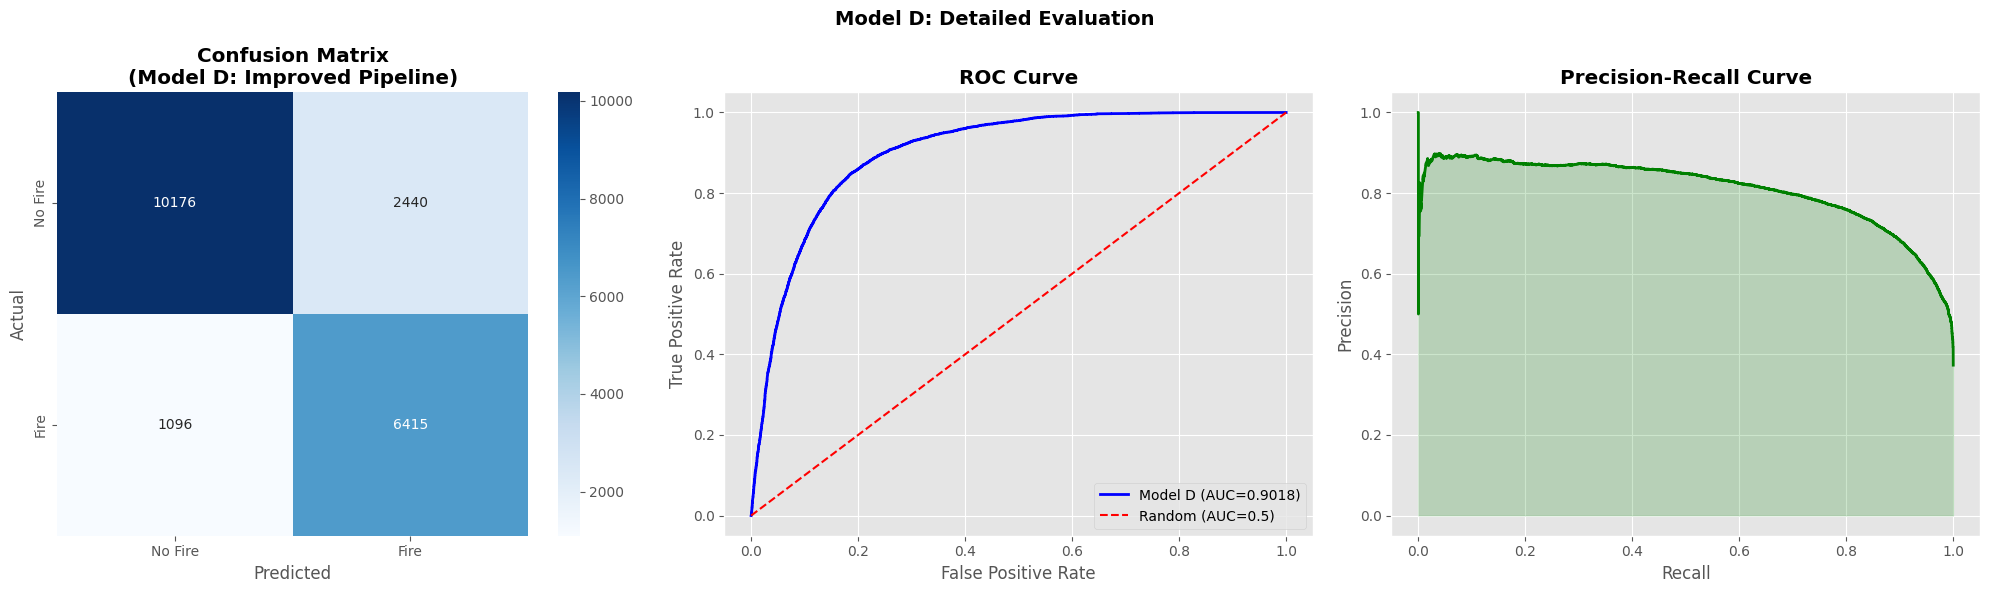

In [15]:
# ============================================================
# 7.1 Confusion Matrix + ROC + PR Curves
# ============================================================
y_test = df_test['fire']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, preds_d)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
axes[0].set_title(f'Confusion Matrix\n(Model D: Improved Pipeline)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Positive  (ทำนายไฟถูก): {tp:,}")
print(f"  True Negative  (ทำนายไม่มีไฟถูก): {tn:,}")
print(f"  False Positive (ทำนายไฟผิด - False Alarm): {fp:,}")
print(f"  False Negative (พลาดไฟจริง - Dangerous!): {fn:,}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_d)
auc_val = roc_auc_score(y_test, probs_d)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Model D (AUC={auc_val:.4f})')
axes[1].plot([0,1],[0,1],'r--', label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# Precision-Recall Curve
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, probs_d)
axes[2].plot(recall_arr, precision_arr, 'g-', linewidth=2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].fill_between(recall_arr, precision_arr, alpha=0.2, color='green')

plt.suptitle('Model D: Detailed Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

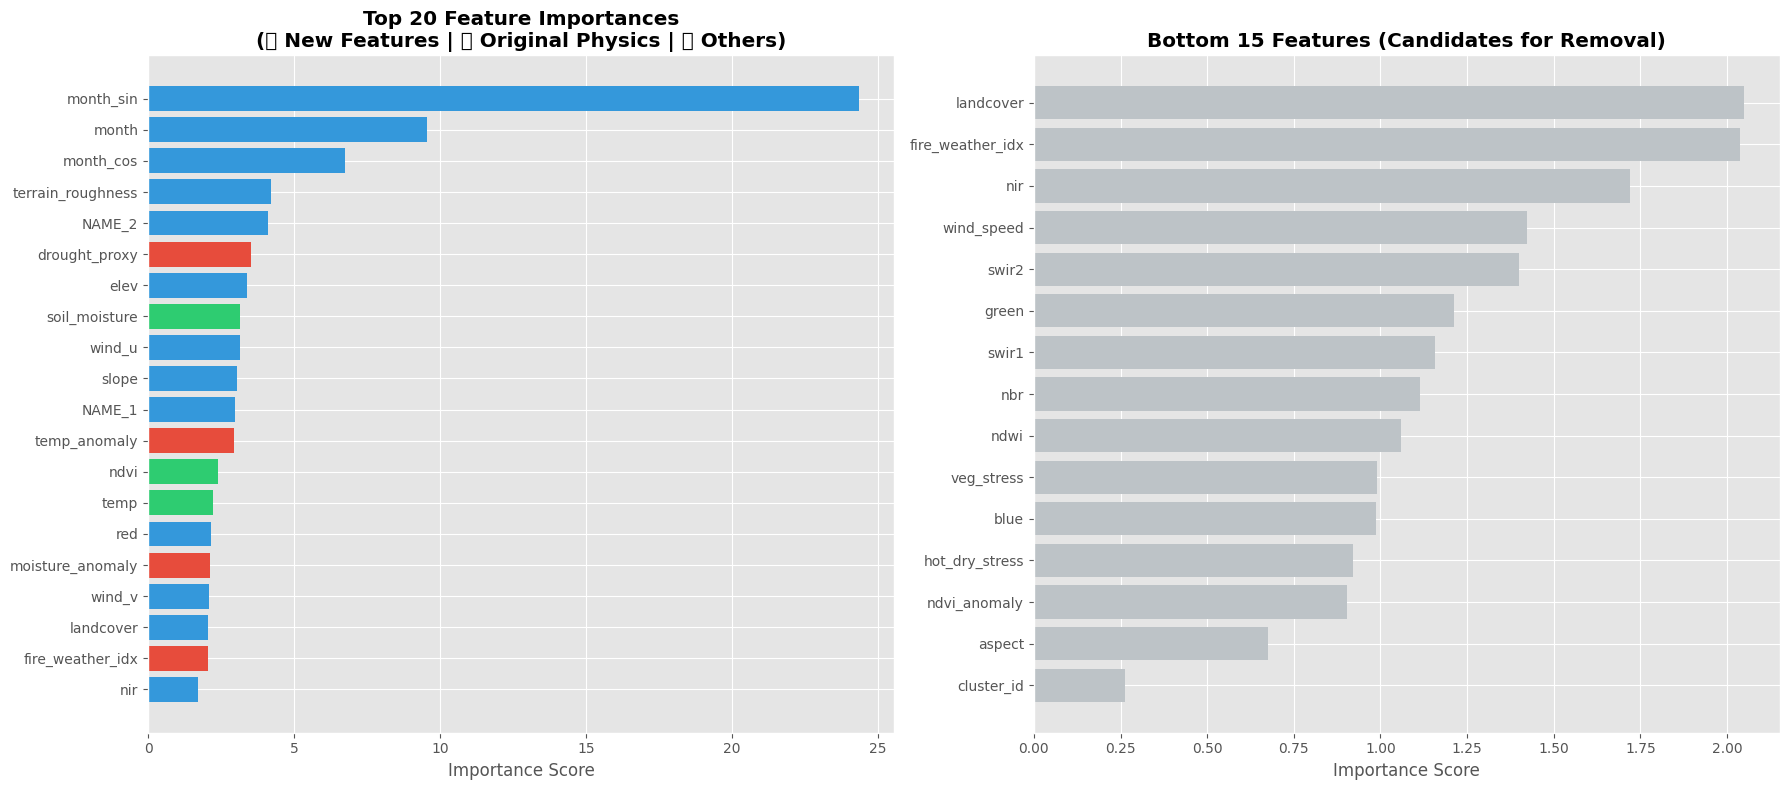


Top 10 Most Important Features:
          feature  importance
        month_sin       24.34
            month        9.54
        month_cos        6.73
terrain_roughness        4.21
           NAME_2        4.09
    drought_proxy        3.51
             elev        3.39
    soil_moisture        3.16
           wind_u        3.15
            slope        3.04

✨ New Engineered Features Performance:
  # 1 month_sin                : 24.34
  # 3 month_cos                : 6.73
  # 4 terrain_roughness        : 4.21
  # 6 drought_proxy            : 3.51
  #12 temp_anomaly             : 2.94
  #16 moisture_anomaly         : 2.13
  #19 fire_weather_idx         : 2.04
  #21 wind_speed               : 1.42
  #27 veg_stress               : 0.99
  #29 hot_dry_stress           : 0.92
  #30 ndvi_anomaly             : 0.90


In [16]:
# ============================================================
# 7.2 Feature Importance
# ============================================================
fi = pd.DataFrame({
    'feature': X_tr_d.columns,
    'importance': model_d.get_feature_importance()
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 20 features
top20 = fi.head(20)
colors_fi = ['#e74c3c' if 'anomaly' in f or 'stress' in f or 'idx' in f or 'drought' in f
             else '#2ecc71' if f in ['ndvi','temp','soil_moisture','nbr','ndwi','nbr']
             else '#3498db'
             for f in top20['feature']]

axes[0].barh(top20['feature'][::-1], top20['importance'][::-1], color=colors_fi[::-1])
axes[0].set_title('Top 20 Feature Importances\n(🔴 New Features | 🟢 Original Physics | 🔵 Others)',
                  fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Bottom features (likely noise)
bottom15 = fi.tail(15)
axes[1].barh(bottom15['feature'][::-1], bottom15['importance'][::-1], color='#bdc3c7')
axes[1].set_title('Bottom 15 Features (Candidates for Removal)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(fi.head(10).to_string(index=False, float_format='%.2f'))

# Highlight new features in ranking
new_feat_ranks = []
for i, row in fi.iterrows():
    if row['feature'] in new_feats:
        rank = fi.index.get_loc(i) + 1
        new_feat_ranks.append((row['feature'], rank, row['importance']))

print("\n✨ New Engineered Features Performance:")
for fname, rank, imp in sorted(new_feat_ranks, key=lambda x: x[1]):
    print(f"  #{rank:2d} {fname:25s}: {imp:.2f}")

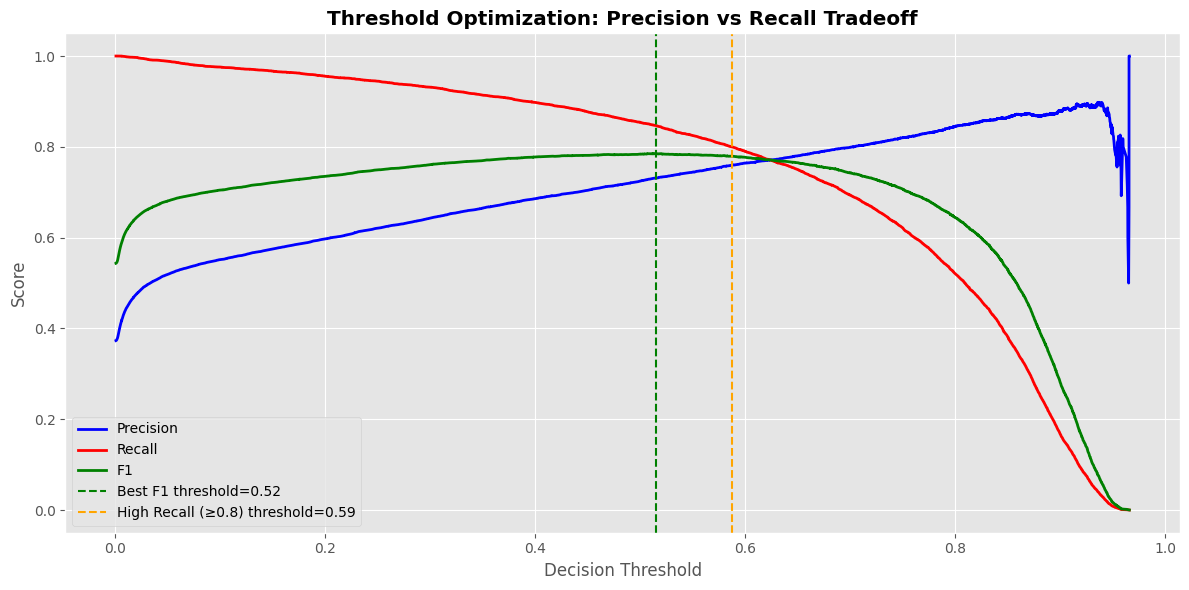


Threshold: Best F1 (t=0.52)
  F1=0.7851  Precision=0.7317  Recall=0.8470

Threshold: High Recall (t=0.59)
  F1=0.7793  Precision=0.7597  Recall=0.8000


In [17]:
# ============================================================
# 7.3 Threshold Optimization for Fire Early Warning
# ============================================================
# สำหรับการแจ้งเตือนภัย: เราต้องการ Recall สูง (พลาดน้อย)
# แต่ Precision ต่ำเกินไปก็จะ false alarm มาก

precision_arr2, recall_arr2, thresholds2 = precision_recall_curve(y_test, probs_d)

# F1 at each threshold
f1_arr = 2 * precision_arr2[:-1] * recall_arr2[:-1] / (precision_arr2[:-1] + recall_arr2[:-1] + 1e-9)

# High recall threshold (for early warning, ~80% recall)
target_recall = 0.80
valid_mask = recall_arr2[:-1] >= target_recall
if valid_mask.any():
    best_threshold_recall = thresholds2[valid_mask][np.argmax(precision_arr2[:-1][valid_mask])]
else:
    best_threshold_recall = 0.5

# Best F1 threshold
best_threshold_f1 = thresholds2[np.argmax(f1_arr)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds2, precision_arr2[:-1], 'b-', label='Precision', linewidth=2)
ax.plot(thresholds2, recall_arr2[:-1], 'r-', label='Recall', linewidth=2)
ax.plot(thresholds2, f1_arr, 'g-', label='F1', linewidth=2)
ax.axvline(best_threshold_f1, color='green', linestyle='--', 
           label=f'Best F1 threshold={best_threshold_f1:.2f}')
ax.axvline(best_threshold_recall, color='orange', linestyle='--', 
           label=f'High Recall (≥{target_recall}) threshold={best_threshold_recall:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization: Precision vs Recall Tradeoff', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Final evaluation at both thresholds
for thr_name, thr in [(f'Best F1 (t={best_threshold_f1:.2f})', best_threshold_f1), 
                       (f'High Recall (t={best_threshold_recall:.2f})', best_threshold_recall)]:
    preds_thr = (probs_d >= thr).astype(int)
    print(f"\nThreshold: {thr_name}")
    print(f"  F1={f1_score(y_test, preds_thr):.4f}  Precision={precision_score(y_test, preds_thr):.4f}  Recall={recall_score(y_test, preds_thr):.4f}")

## 8. 🗺️ Error Analysis by Province & Month
### วิเคราะห์ว่าโมเดลพลาดที่ไหนและเมื่อไหร่

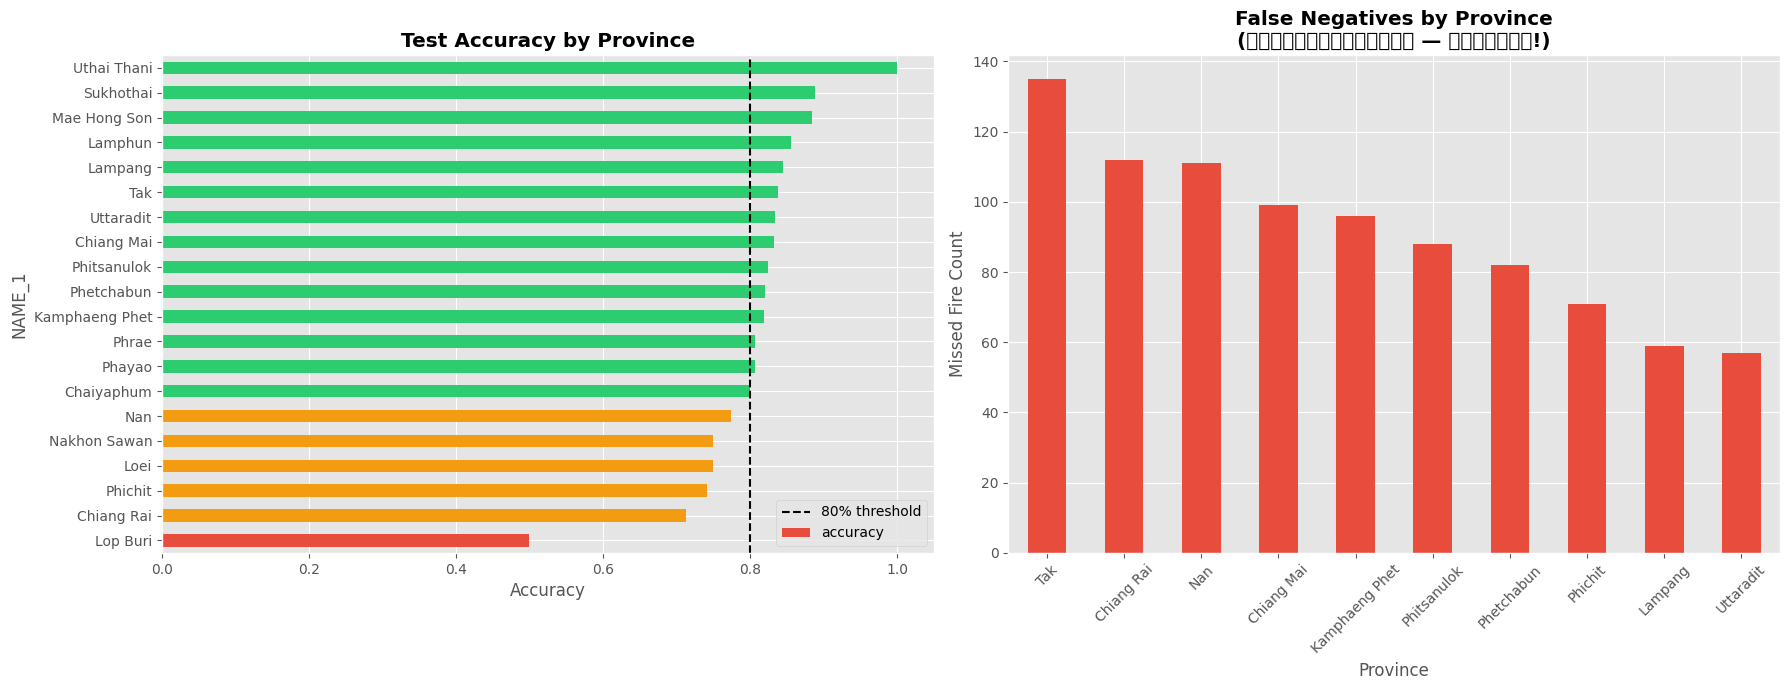


Performance by Month (Test 2025):
         count  fire_rate    f1  recall
month                                  
1     1755.000      0.389 0.663   0.676
2     2145.000      0.500 0.772   0.955
3     4913.000      0.783 0.895   0.971
4     2176.000      0.508 0.715   0.905
5     1351.000      0.178 0.394   0.367
6     1037.000      0.017 0.105   0.056
7      940.000      0.004 0.000   0.000
8     1098.000      0.059 0.116   0.062
9     1065.000      0.003 0.667   0.667
10    1067.000      0.026 0.286   0.179
11    1147.000      0.078 0.165   0.101
12    1433.000      0.248 0.348   0.237


In [18]:
# ============================================================
# 8.1 Province-level error analysis
# ============================================================
df_test_result = df_test.copy()
df_test_result['prob'] = probs_d
df_test_result['pred'] = preds_d
df_test_result['correct'] = (df_test_result['pred'] == df_test_result['fire']).astype(int)

# Province accuracy
province_acc = df_test_result.groupby('NAME_1').agg(
    total=('fire', 'count'),
    fire_actual=('fire', 'sum'),
    fire_pred=('pred', 'sum'),
    accuracy=('correct', 'mean'),
    fn=('fire', lambda x: ((x == 1) & (df_test_result.loc[x.index, 'pred'] == 0)).sum()),
    fp=('fire', lambda x: ((x == 0) & (df_test_result.loc[x.index, 'pred'] == 1)).sum())
).sort_values('accuracy')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Accuracy by province
province_acc['accuracy'].sort_values().plot(kind='barh', ax=axes[0], 
                                             color=['#e74c3c' if v < 0.7 else '#f39c12' if v < 0.8 else '#2ecc71' 
                                                    for v in province_acc['accuracy'].sort_values()])
axes[0].axvline(0.8, color='black', linestyle='--', label='80% threshold')
axes[0].set_title('Test Accuracy by Province', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].legend()

# False Negatives (missed fires) by province — most dangerous!
province_acc['fn'].sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('False Negatives by Province\n(ไฟที่โมเดลพลาด — อันตราย!)', fontweight='bold')
axes[1].set_xlabel('Province')
axes[1].set_ylabel('Missed Fire Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Month-level performance
month_perf = df_test_result.groupby('month').apply(
    lambda g: pd.Series({
        'count': len(g),
        'fire_rate': g['fire'].mean(),
        'f1': f1_score(g['fire'], g['pred'], zero_division=0),
        'recall': recall_score(g['fire'], g['pred'], zero_division=0)
    })
)
print("\nPerformance by Month (Test 2025):")
print(month_perf.to_string(float_format='%.3f'))

## 9. 💾 Save & Summary
### บันทึกโมเดลและสรุปผล

In [19]:
# ============================================================
# 9.1 Save Model
# ============================================================
model_d.save_model('wildfire_improved_model_d.cbm')
print("✅ Model saved: wildfire_improved_model_d.cbm")

# Save feature list
feature_list = list(X_tr_d.columns)
pd.Series(feature_list).to_csv('model_d_features.csv', index=False, header=['feature'])
print(f"✅ Feature list saved: {len(feature_list)} features")

# ============================================================
# 9.2 Final Summary Report
# ============================================================
print("\n" + "="*70)
print("📋 FINAL SUMMARY REPORT")
print("="*70)

print("\n🔴 ปัญหาที่พบและแก้ไข:")
print("  1. Data Leakage: ลบ MODIS detection columns (BRIGHTNESS, FRP, CONFIDENCE, etc.)")
print("     เหตุผล: คอลัมน์เหล่านี้มีค่าเฉพาะ fire=1 เท่านั้น = โมเดลโกง")
print("  2. Simulated Features: ไม่ใช้ road_density หรือ rel_humidity ที่ simulate จาก label")
print("  3. Anomaly Leakage: คำนวณ baseline จาก train เท่านั้น แล้วค่อย apply ไปยัง test")
print("  4. Clustering: ใช้ Silhouette Score หาค่า K ที่เหมาะสม ไม่ใช่แค่สมมติ")

print("\n✅ สิ่งที่ปรับปรุง:")
print("  1. Feature Engineering ใหม่ที่มีความหมายทาง Physics:")
print("     - veg_stress: Dry Fuel Index (swir1-nir)/(swir1+nir)")
print("     - fire_weather_idx: temp × (1 - moisture)")
print("     - drought_proxy: (1-ndvi) × (1-moisture)")
print("     - hot_dry_stress: temp × veg_stress")
print("     - wind_speed: sqrt(u² + v²)")
print("     - terrain_roughness: slope × log(elev)")
print("  2. Anomaly Features (leak-free): ndvi_anomaly, moisture_anomaly, temp_anomaly")
print("  3. Cyclical Month Encoding: sin/cos แทน raw integer")
print("  4. Temporal Split ที่เข้มงวด: 2023-2024 = train, 2025 = test")
print("  5. Threshold Optimization สำหรับ Early Warning")

print("\n📊 Model Performance Summary:")
print(results_df.to_string(float_format='%.4f'))

print("\n💡 คำแนะนำการใช้งาน:")
print(f"  - ใช้ threshold={best_threshold_f1:.2f} สำหรับ balanced performance")
print(f"  - ใช้ threshold={best_threshold_recall:.2f} สำหรับ early warning (recall สูง, false alarm มากขึ้น)")
print("  - โมเดลทำงานได้ดีที่สุดในช่วง มี.ค.-เม.ย. (Hot-Dry Season)")
print("  - ควร retrain ทุกปีเมื่อมีข้อมูลใหม่")
print("="*70)

✅ Model saved: wildfire_improved_model_d.cbm
✅ Feature list saved: 32 features

📋 FINAL SUMMARY REPORT

🔴 ปัญหาที่พบและแก้ไข:
  1. Data Leakage: ลบ MODIS detection columns (BRIGHTNESS, FRP, CONFIDENCE, etc.)
     เหตุผล: คอลัมน์เหล่านี้มีค่าเฉพาะ fire=1 เท่านั้น = โมเดลโกง
  2. Simulated Features: ไม่ใช้ road_density หรือ rel_humidity ที่ simulate จาก label
  3. Anomaly Leakage: คำนวณ baseline จาก train เท่านั้น แล้วค่อย apply ไปยัง test
  4. Clustering: ใช้ Silhouette Score หาค่า K ที่เหมาะสม ไม่ใช่แค่สมมติ

✅ สิ่งที่ปรับปรุง:
  1. Feature Engineering ใหม่ที่มีความหมายทาง Physics:
     - veg_stress: Dry Fuel Index (swir1-nir)/(swir1+nir)
     - fire_weather_idx: temp × (1 - moisture)
     - drought_proxy: (1-ndvi) × (1-moisture)
     - hot_dry_stress: temp × veg_stress
     - wind_speed: sqrt(u² + v²)
     - terrain_roughness: slope × log(elev)
  2. Anomaly Features (leak-free): ndvi_anomaly, moisture_anomaly, temp_anomaly
  3. Cyclical Month Encoding: sin/cos แทน raw integer
  4. Tem